In [1]:
# (데이터 증강 + CNN 개선)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 학습 데이터 불러오기
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/OSS/dataset/raw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 1574 files belonging to 4 classes.
Using 1260 files for training.
Found 1574 files belonging to 4 classes.
Using 314 files for validation.


In [3]:
# 클래스 이름
class_names = train_ds.class_names

print("클래스 목록")
print(class_names)

클래스 목록
['can', 'paper', 'plastic', 'vinyl']


In [4]:
# 데이터 증강
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [5]:
# 모델 생성
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [6]:
# 컴파일

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# 조기종료
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

In [9]:
# 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8810 - loss: 0.3094 - val_accuracy: 0.7739 - val_loss: 0.6996
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.8802 - loss: 0.3165 - val_accuracy: 0.7834 - val_loss: 0.6819
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.8754 - loss: 0.3200 - val_accuracy: 0.8089 - val_loss: 0.6242
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.8992 - loss: 0.2934 - val_accuracy: 0.8153 - val_loss: 0.6426
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8794 - loss: 0.3071 - val_accuracy: 0.7580 - val_loss: 0.7100
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8548 - loss: 0.3998 - val_accuracy: 0.7803 - val_loss: 0.6249
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9119 - loss: 0.2462 - val_accuracy: 0.7834 - val_loss: 0.6586
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.9056 - loss: 0.2621 - val_accuracy: 0.7803 - v

In [10]:
# 평가
loss, acc = model.evaluate(val_ds)

print(f"Validation Accuracy : {acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8153 - loss: 0.6426
Validation Accuracy : 0.8153


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

In [12]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[44  3  3  3]
 [ 1 69 19  7]
 [ 2  4 71  8]
 [ 1  2  5 72]]


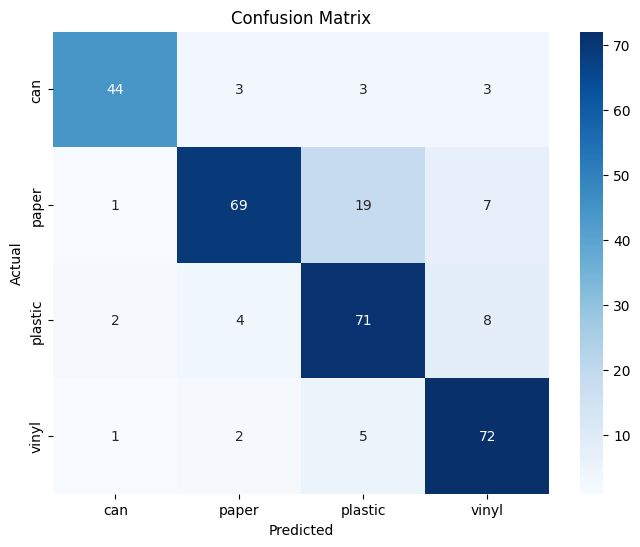

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
# 모델 저장
model.save(
    "/content/drive/MyDrive/OSS/AI/model/recycle_model_v4.keras"
)

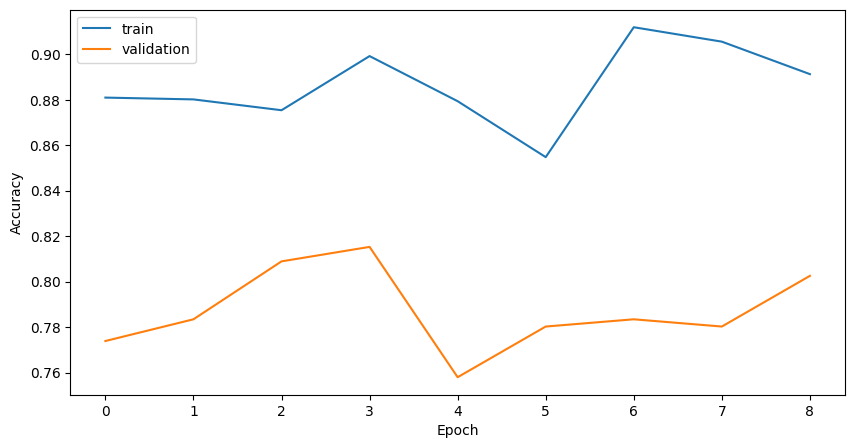

In [16]:
import matplotlib.pyplot as plt

# 그래프
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [18]:
print(history.history['val_loss'])
print(history.history['val_accuracy'])

[0.6996376514434814, 0.681868314743042, 0.6241666674613953, 0.6426242589950562, 0.7099536657333374, 0.6248706579208374, 0.6586147546768188, 0.8028392195701599, 0.7594187259674072]
[0.7738853693008423, 0.7834395170211792, 0.808917224407196, 0.8152866363525391, 0.7579618096351624, 0.7802547812461853, 0.7834395170211792, 0.7802547812461853, 0.8025477528572083]


In [17]:
print(max(history.history['val_accuracy']))

0.8152866363525391
